# NASA EPSCoR Progress: Mach-Zehnder Dynamic Locking
### 20260615 - *Tyndale Stutzman*
---

## Introduction:

The purpose of this notebook is to provide a brief overview of the control theory used to characterize the current feedback system for the initial table-top phase of the Programmable Photonics for Quantum Space Networks project. More details of the optics, electronics, and methods used thus far can be found in [this preliminary notebook](linkhere). <!-- working on turning my doc report into a notebook too -->

## Table of Contents

1. [Step 0: Background](#background)
   1. [System Refresher](#system)
   2. [Control Theory Overview](#theory)
   3. [PID Review](#review)
2. [Step 1: Setup](#setup)
   1. [Environment & Packages](#env)
   2. [PID Configuration](#pid)
   3. [VNA Sweep](#vna)
   4. [Plotting](#plot)
3. [Step 2: Save Data](#save)
4. [Step 3: Analysis](#analysis)
5. 


<a id="background"></a>
## Step 0: Background
<a id="system"></a>
### System Refresher

Before diving into the PID parameters and analysis code, below are graphics of the system architecture and optical schematic which can be helpful in understanding the components at play. 

#### **Figure 1. System Architecture**

In this diagram, the key is to follow the chain of components from ```out1``` and back into ```in1``` on the **Red Pitaya**.

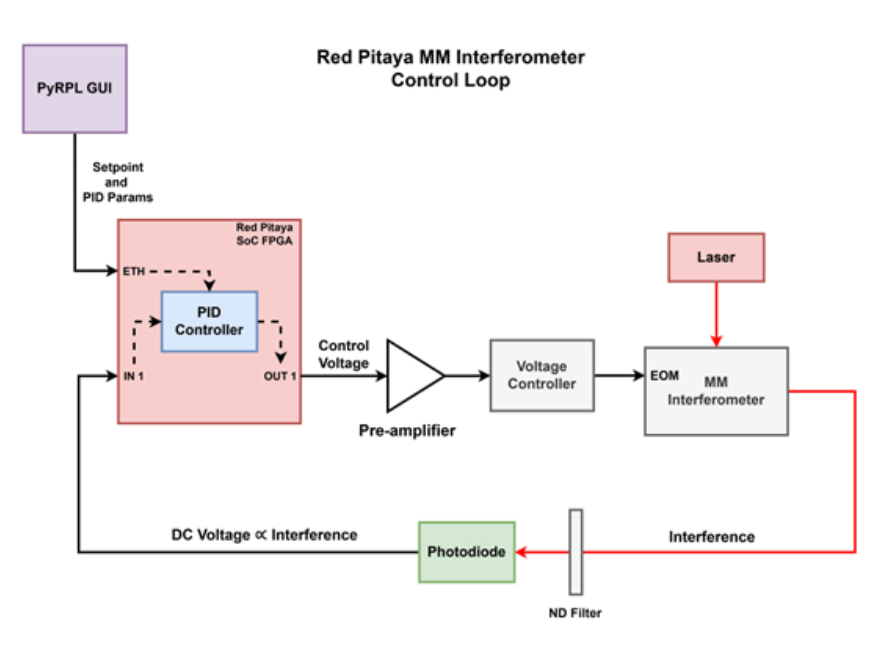


#### **Figure 2. Optical Schematic**

For the optics half of this experiment, the **plant** is isolated as only the **MMI** which is placed after the beam expander **L1**. For this work, optical components before **L1** are not considered to be a part of the system under examination. 

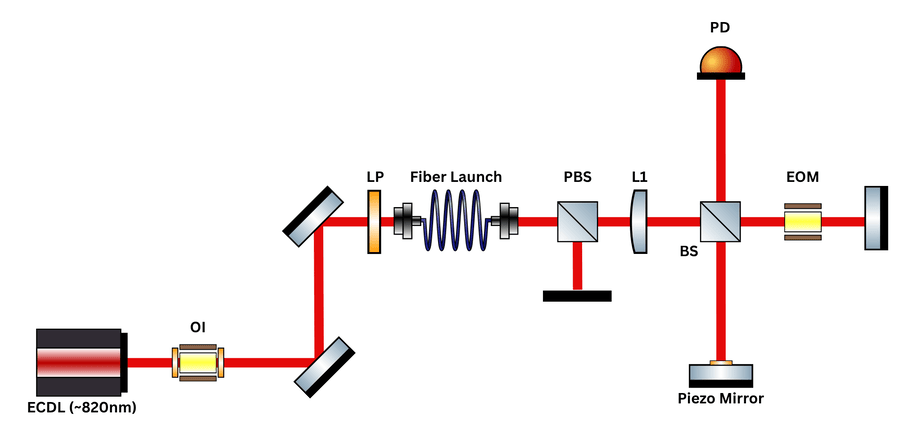


<a id="theory"></a>
### Control Theory Overview

Fundamentally, control theory is concerned with stabilization: given a dynamical system with a drifting or unstable output, feedback is used to regulate the system about a desired operating point. In a standard negative-feedback architecture, a reference signal $R(s)$ is compared to a measured output $Y(s)$ to produce an error signal $E(s)$,

$$
E(s) = R(s) - U_{\mathrm{fb}}(s),
$$

where the feedback signal is generated by the feedback path transfer function $H(s)$, which in this work is simply the PID,

$$
U_{\mathrm{fb}}(s) = H(s)Y(s).
$$

The error signal drives the plant $G(s)$,

$$
Y(s) = G(s)E(s).
$$

In this experiment, all physical signals originate as real-valued time-domain quantities. However, feedback systems are most naturally analyzed in the Laplace domain, where differentiation and integration become multiplication and division respectively. This framework simplifies the description of controller dynamics, loop gain, and stability.

The plant transfer function $G(s)$ represents the complete optical-electrical system being stabilized. In practice, $G(s)$ is a composite transfer function consisting of multiple subsystems such as

$$
G(s) = G_{\mathrm{EOM}}(s)\,G_{\mathrm{PD}}(s)\,G_{\mathrm{RP}}(s)\,\cdots
$$

where the individual factors represent the actuator, photodetection chain, Red Pitaya electronics, and any additional dynamics present in the loop.

For this particular feedback architecture, the open loop transfer function is defined as follows:

$$
\boxed{
P(s) = G(s) = \left(\frac{u}{y}\right)^{-1}
}
$$

Returning to the error function, substituting $E(s)=R(s)-H(s)Y(s)$ into $Y(s)=G(s)E(s)$ and rearranging gives

$$
Y(s)\bigl(1+G(s)H(s)\bigr)=G(s)R(s),
$$

from which we arrive at the closed loop transfer function

$$
\boxed{
T(s) =
\frac{Y(s)}{R(s)} =
\frac{G(s)}
{1+G(s)H(s)}
}.
$$

---

For measurement, a VNA sweep is performed while the interferometer remains locked. The system is assumed to operate about a steady-state equilibrium point, allowing the dynamics to be treated as a small-signal linearization of the full nonlinear system. A sinusoidal excitation is injected through the Red Pitaya and the resulting complex response is recorded as a frequency-dependent transfer function.

Since the Red Pitaya directly measures $T(s)$ through ```data = na.single()```, we can trivially reconstruct the open loop transfer function algebraically.

$$
G(s)=\frac{T(s)}{1-T(s)H(s)},
$$

Throughout this notebook, the electro-optic modulator (EOM) serves as the primary actuator where both locking and control are implemented through the same feedback path.

<a id="review"></a>
### PID Review

With the feedback structure defined, we can take a closer look at $H(s)$ and how it contributes to the closed loop gain $T(s)$.

The PID controller takes an error signal as its input

$$
e(t) = r(t) - y(t)
$$

and generates a control signal

$$
u(t) = K_P e(t) + K_I \int e(t)\,dt + K_D \frac{de(t)}{dt}
$$

This structure combines proportional, integral, and derivative actions, which are effectively correction, suppression, and damping.

Taking the Laplace transform gives

$$
U(s) = \left(K_P + \frac{K_I}{s} + K_D s \right) E(s)
$$

Therefore, the controller transfer function is

$$
H(s) = \frac{U(s)}{E(s)} = K_P + \frac{K_I}{s} + K_D s
$$

---

The controller enters the feedback loop through the product $G(s)H(s)$, which appears directly in the closed-loop transfer function

$$
T(s)=\frac{G(s)}{1+G(s)H(s)}.
$$

Consequently, adjustments to $K_P$, $K_I$, and $K_D$ modify the loop gain and therefore the bandwidth, stability margins, and disturbance rejection of the closed-loop system.

In particular:

- $K_P$ sets midband loop gain (stiffness and response speed)
- $K_I$ dominates low-frequency gain and determines steady-state error suppression
- $K_D$ contributes high-frequency phase lead and improves damping (not necesary for our PI formulation.)

---

In this experiment, PID parameters for both the piezo and EOM configurations were determined using the [Ziegler–Nichols tuning method](https://en.wikipedia.org/wiki/Ziegler%E2%80%93Nichols_method), which estimates gains based on the onset of sustained oscillation, called the ultimate gain.


<a id="setup"></a>
## Step 1: Setup

<a id="env"></a>
### Environment and Packages

For the following script, simply run this notebook within the environment where you have run ```pip install -e /your/path/to/pyrpl```.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
import time
from pyrpl import Pyrpl, logger, logging
logging.disable(logging.WARNING) # Make the program less verbose

In [2]:
# Establish Red Pitaya connection

HOSTNAME = "192.168.1.98"
CONFIG_NAME = "scope_config"
p = Pyrpl(hostname=HOSTNAME, config=CONFIG_NAME)

<a id="config"></a>
### PID Configuration
* *These values were calculated via the Ziegler-Nichols method and can be adjusted for the Piezo or EOM depending on the desired measurement.*

In [3]:
# Setting PI coefficients and input/outputs
pid = p.rp.pid1
pid.input = 'in1'
pid.output_direct = 'out1'
overall_gain_factor = 1.7

'''
# For piezo values
pid.p = 0.9 * overall_gain_factor
pid.i = 1000 * overall_gain_factor
pid.setpoint = 0.41
'''

# For EOM values
pid.p = 6.9 * overall_gain_factor
pid.i = 7900 * overall_gain_factor
pid.setpoint = 0.41


In [4]:
def relock(pd, P=None, I=None, setpoint=None):
    """Engage PID loop with defined parameters."""
    pd.pause_gains = 'i'
    pd.paused = True
    pd.ival = 0.0

    if P is not None:
        pd.p = P
    if I is not None:
        pd.i = I
    if setpoint is not None:
        pd.setpoint = setpoint

    pd.setpoint = setpoint
    pd.paused = False


def unlock(pd):
    """Disable PID loop (open loop)."""
    pd.pause_gains = 'i'
    pd.paused = True
    pd.ival = 0.0


def reset(pd, P=None, I=None, setpoint=None):
    """Reset integrator and relock."""
    unlock(pd)
    time.sleep(1)
    relock(pd, P=P, I=I, setpoint=setpoint)

def status(pid):
    """Print current PID state."""
    print("\n--- PID STATUS ---")
    print(f"P: {pid.p}")
    print(f"I: {pid.i}")
    print(f"Setpoint: {pid.setpoint}")
    print(f"Paused: {pid.paused}")
    print(f"I term: {pid.ival}")
    print("------------------\n")

In [5]:
relock(pid, P=pid.p, I=pid.i, setpoint=pid.setpoint)

In [6]:
unlock(pid)

In [7]:
reset(pid, P=pid.p, I=pid.i, setpoint=pid.setpoint)

In [8]:
status(pid)


--- PID STATUS ---
P: 11.72998046875
I: 13430.000268899366
Setpoint: 0.4100341796875
Paused: False
I term: -4.0
------------------



#### * *as a quick note, it's worth running these locking functions a few times to verify that they're working. Also, if it's having trouble locking, play around with different setpoints.*

<a id="vna"></a>
### VNA Sweep

With locking and unlocking functions working properly, we can proceed to running a VNA sweep to probe the system. Below are the VNA parameters which will determine the quality of our measurement.

In [9]:
# Network analyzer parameters
F_START = 8e2
F_STOP = 60e3
POINTS = 501
RBW = 100
AVG_PER_POINT = 5
EXCITATION_AMP = 0.01

##### **NOTE: before running the sweep, ensure that the lock is stable and persistent in order to ensure accurate measurement. Any temporary unlocking will require a rerun of the sweep.**

In [10]:
def run_sweep(p, pid):
    """
    Run a network analyzer sweep.

    Returns
    -------
    freq : ndarray
        Frequency axis [Hz]

    data : ndarray
        Complex transfer function measured by the network analyzer.
    """

    if pid.paused:
        raise RuntimeError("Loop is unlocked. Refusing to run sweep.")

    na = p.networkanalyzer

    na.setup(
        start_freq=F_START,
        stop_freq=F_STOP,
        logscale=True,
        points=POINTS,
        rbw=RBW,
        avg_per_point=AVG_PER_POINT,
        amplitude=EXCITATION_AMP,
        acbandwidth=0,
        sleepcycles=0.1,
        input="in1",
        output_direct="out1",
        trace_average=1,
    )

    print("Running sweep...")

    t0 = time.time()
    data = na.single()
    t1 = time.time()

    print(f"Sweep completed in {t1 - t0:.2f} s")

    freq = na.frequencies

    return freq, data

In [17]:
# Run the sweep

freq, data = run_sweep(p, pid)

Running sweep...
Sweep completed in 16.06 s


<a id="plot"></a>
### Plotting

Now, with the closed loop transfer function measured, ```cltf = data```, the open loop transfer function can be reconstructed and plotted.

In [18]:
# PID transfer function
pid_tf = pid.transfer_function(freq)

# Closed-loop transfer function (direct measurement)
cltf = data

# Inferred open-loop transfer function
oltf = data / (1 - data * pid_tf)

# Loop Gain
loop_gain = oltf * pid_tf

In [19]:
def plot_transfer_function(freq, tf, title, label, color):
    
    mag_db = 20 * np.log10(np.abs(tf))

    phase_deg = np.unwrap(np.angle(tf)) * 180 / np.pi
    phase_deg -= phase_deg[0]

    fig, axs = plt.subplots(
        2, 1,
        figsize=(10, 7),
        sharex=True
    )

    axs[0].plot(freq, mag_db, color=color, label=label)
    axs[0].set_xscale("log")
    axs[0].set_ylabel("Magnitude (dB)")
    axs[0].set_title(title)
    axs[0].grid(True, which="both", ls="--", alpha=0.4)
    axs[0].legend()

    axs[1].plot(freq, phase_deg, color=color, label=label)
    axs[1].set_xscale("log")
    axs[1].set_xlabel("Frequency (Hz)")
    axs[1].set_ylabel("Phase (deg)")
    axs[1].grid(True, which="both", ls="--", alpha=0.4)
    axs[1].legend()

    fig.tight_layout()

    return fig

### Closed Loop Transfer Function

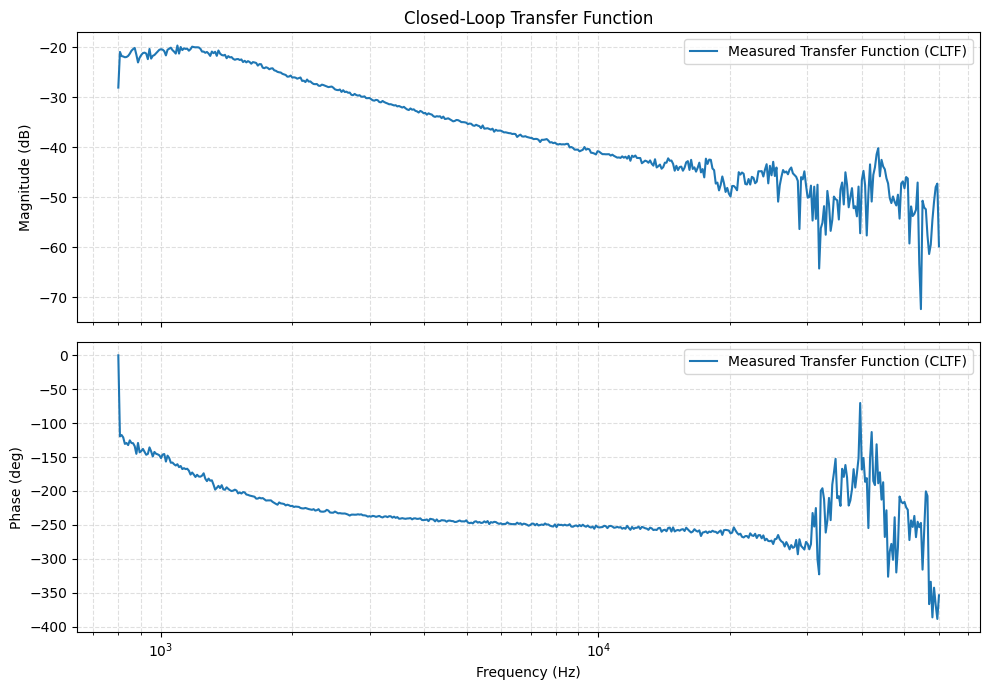

In [20]:
fig_cltf = plot_transfer_function(
    freq=freq,
    tf=cltf,
    title="Closed-Loop Transfer Function",
    label="Measured Transfer Function (CLTF)",
    color="tab:blue"
)

### Open Loop Transfer Function

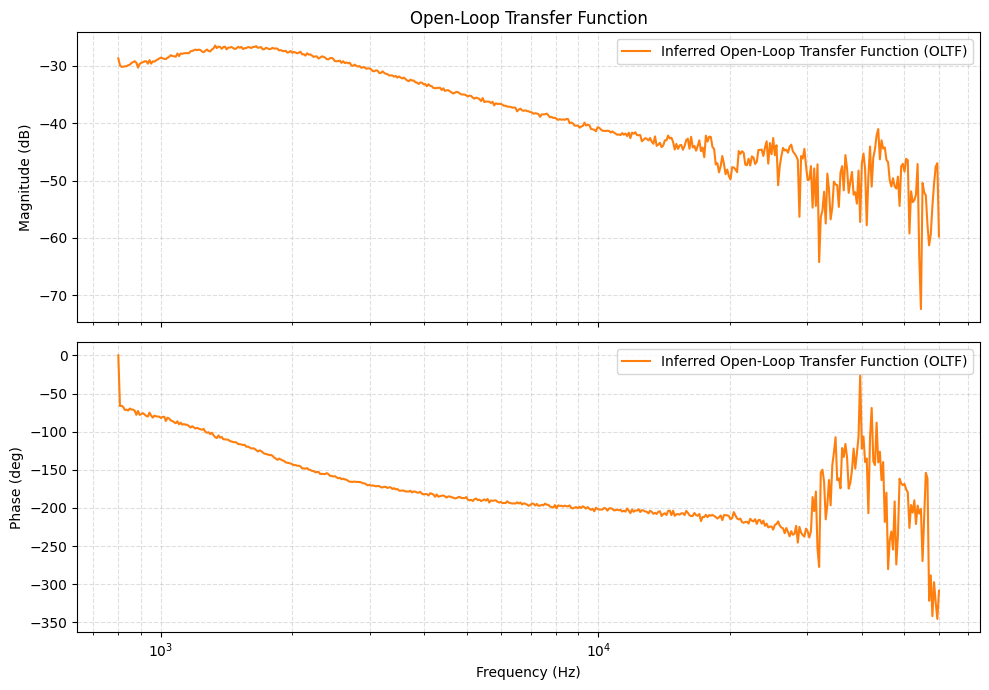

In [21]:
fig_oltf = plot_transfer_function(
    freq,
    oltf,
    "Open-Loop Transfer Function",
    "Inferred Open-Loop Transfer Function (OLTF)",
    "tab:orange"
)

### Loop Gain

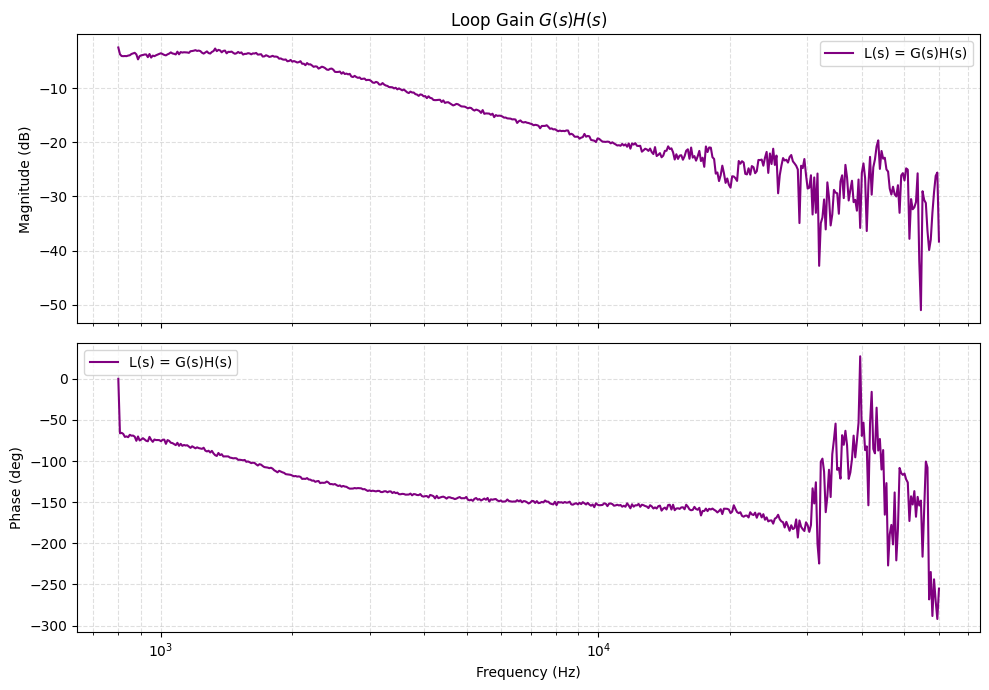

In [22]:
fig_L = plot_transfer_function(
    freq,
    loop_gain,
    title="Loop Gain $G(s)H(s)$",
    label="L(s) = G(s)H(s)",
    color="purple"
)

<a id="save"></a>
## Step 2: Save Data

Save plots and data to csv.

In [116]:
# Base filename for this measurement

from datetime import datetime

SAVE_NAME = "MZ-EOM-Piezo-third_run"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

FILE_PREFIX = f"{SAVE_NAME}_{timestamp}"

In [117]:
# Save figures

cltf_filename = f"{FILE_PREFIX}-cltf.png"
oltf_filename = f"{FILE_PREFIX}-oltf.png"
L_filename = f"{FILE_PREFIX}-gh.png"

fig_cltf.savefig(
    cltf_filename,
    dpi=300,
    bbox_inches="tight"
)

fig_oltf.savefig(
    oltf_filename,
    dpi=300,
    bbox_inches="tight"
)

fig_L.savefig(
    L_filename,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved: {cltf_filename}")
print(f"Saved: {oltf_filename}")
print(f"saved: {L_filename}")

Saved: MZ-EOM-Piezo-third_run_20260616_212930-cltf.png
Saved: MZ-EOM-Piezo-third_run_20260616_212930-oltf.png
saved: MZ-EOM-Piezo-third_run_20260616_212930-gh.png


In [118]:
import csv

csv_filename = f"{FILE_PREFIX}-vna_sweep.csv"

with open(csv_filename, "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow([
        "frequency_Hz",
        "cltf_real", "cltf_imag",
        "oltf_real", "oltf_imag"
    ])

    for i in range(len(freq)):
        writer.writerow([
            freq[i],
            np.real(cltf[i]),
            np.imag(cltf[i]),
            np.real(oltf[i]),
            np.imag(oltf[i]),
        ])

print(f"Saved: {csv_filename}")

Saved: MZ-EOM-Piezo-third_run_20260616_212930-vna_sweep.csv


<a id="analysis"></a>
## Step 3: Analysis

Having applied the [Step 0 review](#background) to produce the above plots, we can take a closer look to consider what these tell us about the system being measured. First, each measurement can physically be thought of in the following ways:

**CLTF:**  the actual measured response of the system while the feedback loop is active. This represents the combined effect of the plant dynamics and the controller's corrective action.

**OLTF:**  the natural response of the physical system without feedback compensation. This reveals the underlying dynamics of the plant, such as resonances, roll-offs, and other frequency-dependent behavior.

**Loop Gain:**  the strength of the feedback correction applied to the system. This indicates how much authority the controller has to supress disturbances and shape the system response.

In each of these transfer functions, features in the gain and phase Bode plots reveal important information about the system dynamics. In the gain response, changes in slope, roll-off regions, and resonant peaks can indicate bandwidth limitations, filtering behavior, or mechanical and electrical resonances. In the phase response, transitions and rapid shifts often accompany these gain features and provide insight into the underlying poles and zeros of the system. By comparing these features across the CLTF, OLTF, and loop gain, we can distinguish between the natural behavior of the plant and the dynamics introduced or suppressed by the feedback loop.

---

### Results

For this specific system, a few things stand out in these plots. Starting with the CLTF, we notice that the gain starts at -20dB. It's important to note that, while absolute gain can be significant for analysis, the scaling of gain in this experiment has not been calculated, i.e. the gain of the various amplifiers, the photodiode, and the Red Pitaya. That being said, if we consider -20dB as our starting point, we see a slight increase in gain moving into a couple kHz and then a sudden roll-off beginning around 5kHz. This is our first notable feature, indicating that the system generally loses control beyond 5kHz. The loop gain approaches a phase of approximately −180° near this region (as seen more clearly in the loop gain plot), which coincides with the frequency where closed-loop behavior begins to degrade.

Moving onto our OLTF plot, we're able to see the bare dynamics of the system in question since $OLTF = G(s)$, the plant. In the gain plot, there's an approximately linear trend in the mid-frequency region changes beginning around 5kHz where a small peak appears ~7.5kHz. This indicates some sort of resonance in the plant around 7.5kHz. Whether mechanical or electrical, this merely means that something in the system naturally amplifies gain in this frequency regime. We can see this window in the phase plot as well where phase transitions from roughly −90° toward −180° across the same frequency range, consistent with a second-order resonant mode. 

Finally, we consider the Loop Gain plot which clearly  resembles a low pass filter. We see a steady response at lower frequencies and a sharp roll-off right at 5kHz. This is diagnostic of a 5kHz bandwidth: the system is able to maintain control up to 5kHz where it is no longer able to effectively surpress disturbances. At the crossover frequency (~5 kHz), the loop gain phase is approximately −90°, indicating moderate phase lag at the point where control authority begins to roll off. This suggests a non-negligible phase margin relative to the −180° instability boundary.

---
### Export this notebook as HTML

In [38]:
from pathlib import Path
import subprocess

# ----------------------------
# Export settings
# ----------------------------

NOTEBOOK_NAME = "Tutorial-MMI_loop_characterization"  # no .ipynb extension

OUTPUT_NAME = f"{SAVE_NAME}-report"

print(f"[EXPORT] Converting {NOTEBOOK_NAME}.ipynb → HTML")

result = subprocess.run(
    [
        "jupyter",
        "nbconvert",
        "--to",
        "html",
        f"{NOTEBOOK_NAME}.ipynb",
        "--output",
        OUTPUT_NAME
    ],
    capture_output=True,
    text=True
)

# ----------------------------
# Error handling
# ----------------------------

if result.returncode == 0:
    print(f"[EXPORT] Success → {OUTPUT_NAME}.html")
else:
    print("[EXPORT] Failed")
    print(result.stderr)

[EXPORT] Converting Tutorial-MMI_loop_characterization.ipynb → HTML
[EXPORT] Success → EOM-00-report.html
